## Scaled-Space Adversarial Training — LSTM (BiLSTM + AttnPool)

**Key idea**: Attack raw LSTM model với scaled inputs (all features ~N(0,1)) → eps perturbation uniform trong standardized space → inverse_transform về raw → save CSV.

Cùng cơ chế với `defense_ResDNN.ipynb` nhưng cho LSTM gốc.

### 1. Import packages

In [ ]:
import os, sys, time, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
import warnings
warnings.filterwarnings('ignore')

from art.estimators.classification import PyTorchClassifier

from art_generator import (
    FGSMAttackGenerator, PGDAttackGenerator, DeepFoolAttackGenerator,
    CWAttackGenerator, MIMAttackGenerator,
)
from utils.masking import get_mutate_indices
from utils.paths import load_attack_config, load_adv_training_config

### 2. Model architecture

In [30]:
class _AttnPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.proj = nn.Linear(d, 1)
    def forward(self, H):
        w = torch.softmax(self.proj(H).squeeze(-1), dim=1)
        return (H * w.unsqueeze(-1)).sum(1)

class _LSTMTabular(nn.Module):
    def __init__(self, step_dim, hidden=256, layers=2, n_classes=12, dropout=0.15, bidir=True):
        super().__init__()
        self.step_dim = step_dim
        self.in_norm = nn.LayerNorm(step_dim)
        self.lstm = nn.LSTM(
            input_size=step_dim, hidden_size=hidden, num_layers=layers,
            batch_first=True, dropout=dropout if layers > 1 else 0.0, bidirectional=bidir,
        )
        d_out = hidden * (2 if bidir else 1)
        self.pool = _AttnPool(d_out)
        self.head = nn.Sequential(
            nn.Linear(d_out, d_out // 2), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(d_out // 2, n_classes),
        )
    def forward(self, x):
        B, F = x.shape
        S = int(math.ceil(F / self.step_dim))
        pad = S * self.step_dim - F
        if pad > 0:
            x = torch.nn.functional.pad(x, (0, pad), value=0.0)
        x = x.view(B, S, self.step_dim)
        x = self.in_norm(x)
        H, _ = self.lstm(x)
        z = self.pool(H)
        return self.head(z)

class _ScaledLSTM(nn.Module):
    """Only used for final raw-space evaluation."""
    def __init__(self, lstm, mean, scale):
        super().__init__()
        self.lstm = lstm
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        x = x.to(torch.float32)
        return self.lstm((x - self.mean_) / self.scale_)

### 3. Load model, data & scaler

In [5]:
DEVICE = 'cpu'

# Load test data
df_test = pd.read_csv('../../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values.astype(np.float32)
y_test = df_test['Label'].values.astype(int)
feature_names = df_test.columns[:-1].tolist()

input_metadata_sc = {'feature_names': feature_names, 'label_column': 'Label'}
mutate_indices = get_mutate_indices(df_test)
print(f'Protected features: {len(mutate_indices)} indices')

# Load LSTM checkpoint
ckpt = torch.load('../../../training/models/framework_lstm_TVAE.pth', map_location=DEVICE, weights_only=False)

lstm_net = _LSTMTabular(
    step_dim=int(ckpt['step_dim']), hidden=int(ckpt['hidden']),
    layers=int(ckpt['layers']), n_classes=int(ckpt['num_classes']),
    dropout=float(ckpt['dropout']), bidir=bool(ckpt['bidir']),
)
lstm_net.load_state_dict(ckpt['state_dict'])
lstm_net.eval().to(DEVICE)

num_classes = int(ckpt['num_classes'])
input_dim = X_test.shape[1]

# Scaler from checkpoint
scaler = ckpt['scaler']

# Scale test data
X_test_sc = scaler.transform(X_test).astype(np.float32)
clip_min_sc = float(X_test_sc.min())
clip_max_sc = float(X_test_sc.max())
print(f'Scaled clip values: ({clip_min_sc:.4f}, {clip_max_sc:.4f})')

Protected features: 12 indices
Scaled clip values: (-9.9528, 143.4404)


In [6]:
# ART classifier: RAW model, SCALED inputs — for attack generation
atk_clf = PyTorchClassifier(
    model=lstm_net,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(clip_min_sc, clip_max_sc),
    device_type=DEVICE,
)

preds = np.argmax(atk_clf.predict(X_test_sc), axis=1)
acc = accuracy_score(y_test, preds)
print(f'Original Accuracy (scaled-space clf): {acc * 100:.2f}%')

# Also create raw-space classifier for final evaluation
scaled_model = _ScaledLSTM(lstm_net, scaler.mean_, scaler.scale_).to(DEVICE)
scaled_model.eval()
raw_clf = PyTorchClassifier(
    model=scaled_model,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)
preds_raw = np.argmax(raw_clf.predict(X_test), axis=1)
print(f'Original Accuracy (raw-space clf):    {accuracy_score(y_test, preds_raw) * 100:.2f}%')

Original Accuracy (scaled-space clf): 68.10%
Original Accuracy (raw-space clf):    68.10%


In [7]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100
    print(f'--- {attack_name} ---')
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Precision: {precision:.2f}%')
    print(f'Recall: {recall:.2f}%')
    print(f'F1 Score: {f1:.4f}')
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'LSTM {attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

### 4. Generate adversarial EVAL samples in SCALED space

Generate from TEST set → save to `adv_eval/lstm_sc/` for fair comparison.

--- LSTM-SC FGSM (before AT) ---
Accuracy: 43.93%
Precision: 44.35%
Recall: 43.93%
F1 Score: 0.4349


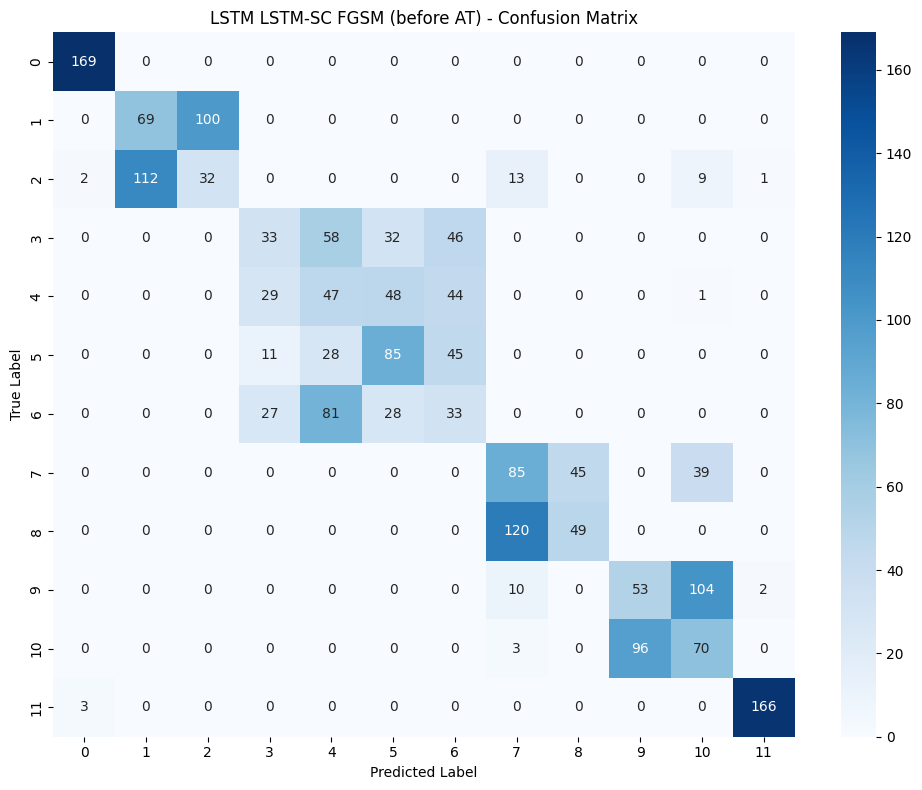

  Runtime: 1.4s | Saved: ../../adv_samples/adv_eval/lstm_sc/lstm_fgsm_adv.csv



--- LSTM-SC PGD (before AT) ---
Accuracy: 35.55%
Precision: 33.59%
Recall: 35.55%
F1 Score: 0.3352


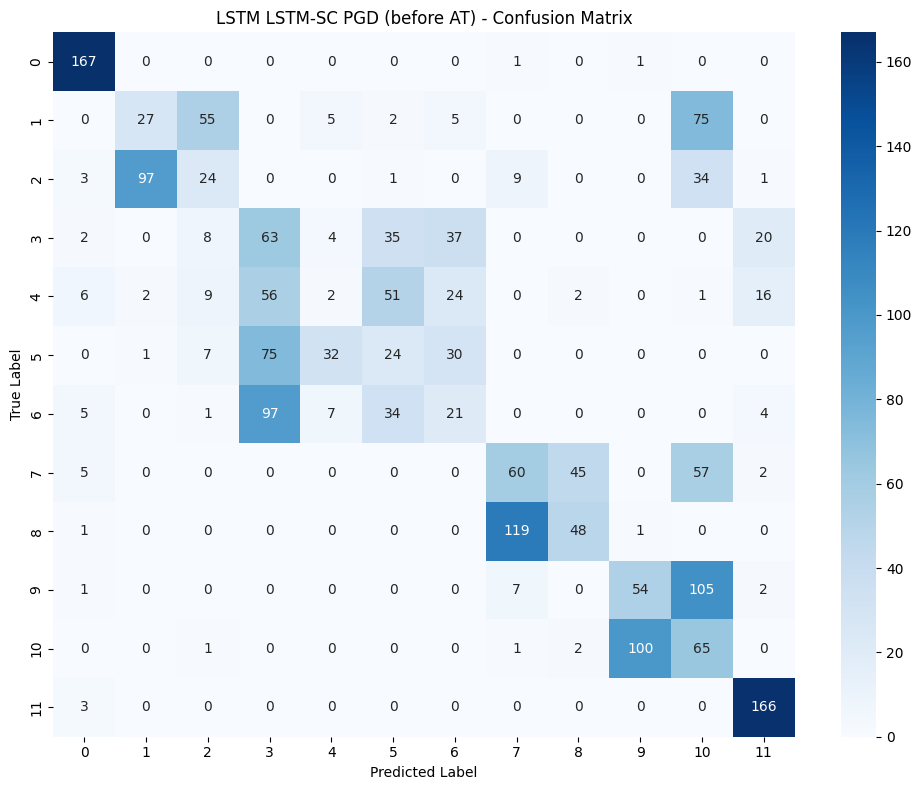

  Runtime: 115.1s | Saved: ../../adv_samples/adv_eval/lstm_sc/lstm_pgd_adv.csv



DeepFool: 100%|██████████| 32/32 [00:13<00:00,  2.40it/s]


--- LSTM-SC DEEPFOOL (before AT) ---
Accuracy: 11.69%
Precision: 14.50%
Recall: 11.69%
F1 Score: 0.1046


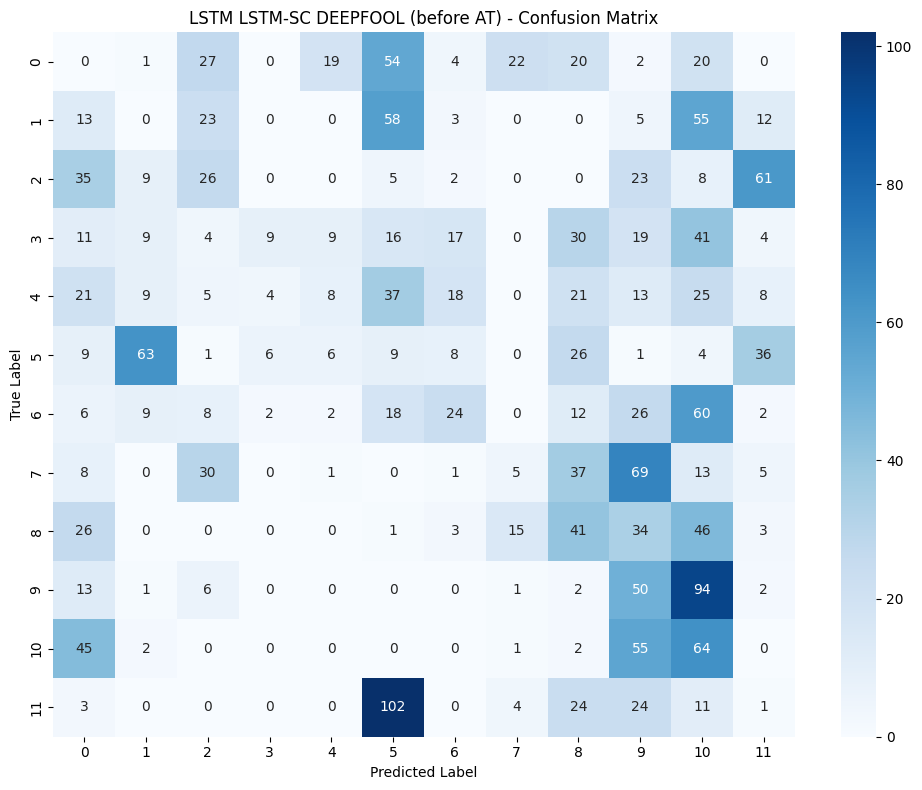

  Runtime: 14.3s | Saved: ../../adv_samples/adv_eval/lstm_sc/lstm_deepfool_adv.csv

--- LSTM-SC CW (before AT) ---
Accuracy: 64.55%
Precision: 63.90%
Recall: 64.55%
F1 Score: 0.6337


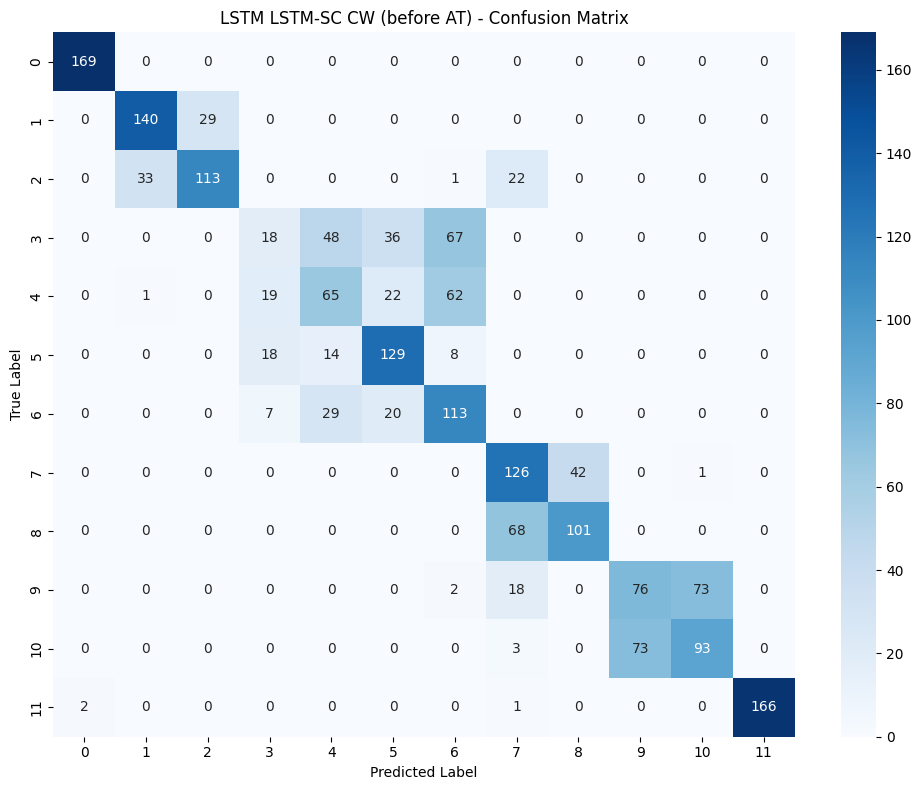

  Runtime: 40.8s | Saved: ../../adv_samples/adv_eval/lstm_sc/lstm_cw_adv.csv



--- LSTM-SC MIM (before AT) ---
Accuracy: 36.49%
Precision: 34.77%
Recall: 36.49%
F1 Score: 0.3486


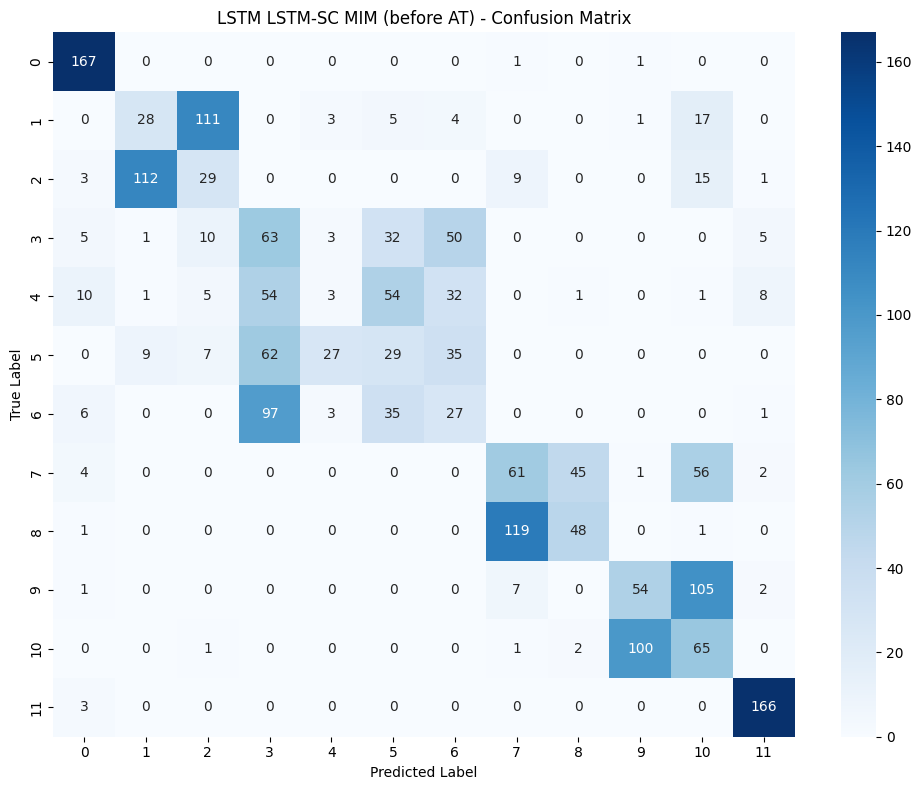

  Runtime: 62.0s | Saved: ../../adv_samples/adv_eval/lstm_sc/lstm_mim_adv.csv



In [19]:
ADV_EVAL_SC_DIR = '../../adv_samples/adv_eval/lstm_sc'
os.makedirs(ADV_EVAL_SC_DIR, exist_ok=True)

eval_attacks = ['fgsm', 'pgd', 'deepfool', 'cw', 'mim']
adv_eval_data = {}

gen_cls_map = {
    'fgsm': FGSMAttackGenerator, 'pgd': PGDAttackGenerator,
    'deepfool': DeepFoolAttackGenerator, 'cw': CWAttackGenerator,
    'mim': MIMAttackGenerator,
}

for atk in eval_attacks:
    cfg = load_attack_config(atk)
    gen = gen_cls_map[atk](atk_clf, generator_params=cfg)

    start_time = time.time()
    df_adv_sc = gen.generate(X_test_sc, y_test, input_metadata_sc, mutate_indices=mutate_indices)
    elapsed = time.time() - start_time

    # Inverse transform: scaled → raw
    X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
    X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
    df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
    df_adv_raw['Label'] = y_test

    out_path = os.path.join(ADV_EVAL_SC_DIR, f'lstm_{atk}_adv.csv')
    df_adv_raw.to_csv(out_path, index=False)

    adv_eval_data[f'lstm_sc_{atk}'] = X_adv_raw

    # Eval on original LSTM (scaled space)
    preds_adv = atk_clf.predict(X_adv_sc)
    evaluate_attack(y_test, preds_adv, f'LSTM-SC {atk.upper()} (before AT)')
    print(f'  Runtime: {elapsed:.1f}s | Saved: {out_path}\n')

### 5. Generate adversarial TRAINING samples in SCALED space

Attack raw model with scaled inputs → eps uniform in standardized space → inverse_transform → save raw CSV.

In [8]:
# Load training data & scale
df_train = pd.read_csv('../../../datasets/augment/train_tvae_9600.csv')
X_train = df_train.drop(columns=['Label']).values.astype(np.float32)
y_train = df_train['Label'].values.astype(int)

X_train_sc = scaler.transform(X_train).astype(np.float32)

ADV_TRAIN_DIR = '../../adv_samples/adv_training/lstm_sc'
os.makedirs(ADV_TRAIN_DIR, exist_ok=True)

print(f'Train set: {X_train.shape}')

Train set: (9600, 66)


#### FGSM (scaled space)

In [9]:
cfg = load_adv_training_config('fgsm')
gen = FGSMAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_fgsm_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

Runtime: 4.00s
Saved 9600 samples


#### PGD (scaled space)

In [10]:
cfg = load_adv_training_config('pgd')
gen = PGDAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_pgd_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

Runtime: 252.76s
Saved 9600 samples


#### DeepFool (scaled space)

In [11]:
cfg = load_adv_training_config('deepfool')
gen = DeepFoolAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_deepfool_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

DeepFool: 100%|██████████| 150/150 [00:55<00:00,  2.69it/s]


Runtime: 57.20s
Saved 9600 samples


#### CW (scaled space)

In [13]:
cfg = load_adv_training_config('cw')
gen = CWAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_cw_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

KeyboardInterrupt: 

#### MIM (scaled space)

In [14]:
cfg = load_adv_training_config('mim')
gen = MIMAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'lstm_mim_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

Runtime: 266.23s
Saved 9600 samples


### 6. Adversarial training — retrain LSTM

In [24]:
# Load & sample adversarial training data
CLEAN_ADV_RATIO = 0.5
n_clean = len(X_train)
n_adv_budget = int(n_clean / CLEAN_ADV_RATIO)

WB_ATTACKS = [
    ('fgsm',     1.5),
    ('pgd',      3.0),
    ('deepfool', 2.5),
    ('cw',       1.5),
    ('mim',      0.5),
]

total_weight = sum(w for _, w in WB_ATTACKS)
rng = np.random.RandomState(42)
parts_X, parts_y = [], []

print(f'Budget: {n_adv_budget} (clean={n_clean}, ratio={CLEAN_ADV_RATIO})\n')

for atk_name, weight in WB_ATTACKS:
    path = os.path.join(ADV_TRAIN_DIR, f'lstm_{atk_name}_train_adv.csv')
    if not os.path.exists(path):
        print(f'  [SKIP] {path}')
        continue

    df = pd.read_csv(path)
    X_atk = df.drop(columns=['Label']).values.astype(np.float32)
    y_atk = df['Label'].values.astype(int)

    n_sample = int(n_adv_budget * weight / total_weight)
    n_sample = min(n_sample, len(X_atk))
    idx = rng.choice(len(X_atk), size=n_sample, replace=False)
    parts_X.append(X_atk[idx])
    parts_y.append(y_atk[idx])
    print(f'  {atk_name:>10s}: {len(X_atk)} -> {n_sample}  (weight={weight})')

# Merge & dedup
adv_X = np.concatenate(parts_X)
adv_y = np.concatenate(parts_y)

X_train_at = np.concatenate([X_train, adv_X])
y_train_at = np.concatenate([y_train, adv_y])

df_tmp = pd.DataFrame(X_train_at)
df_tmp['_lbl'] = y_train_at
n_before = len(df_tmp)
df_tmp = df_tmp.drop_duplicates()
X_train_at = df_tmp.drop(columns=['_lbl']).values.astype(np.float32)
y_train_at = df_tmp['_lbl'].values.astype(int)

print(f'\nClean: {n_clean} | Adv: {len(adv_X)} | Dedup: {n_before - len(df_tmp)}')
print(f'AT train: {X_train_at.shape}')
print(f'\nLabel distribution:\n{pd.Series(y_train_at).value_counts().sort_index()}')

Budget: 19200 (clean=9600, ratio=0.5)



        fgsm: 9600 -> 3200  (weight=1.5)
         pgd: 9600 -> 6400  (weight=3.0)
    deepfool: 9600 -> 5333  (weight=2.5)
  [SKIP] ../../adv_samples/adv_training/lstm_sc/lstm_cw_train_adv.csv
         mim: 9600 -> 1066  (weight=0.5)

Clean: 9600 | Adv: 15999 | Dedup: 20
AT train: (25579, 66)

Label distribution:
0     2095
1     2131
2     2117
3     2121
4     2120
5     2119
6     2161
7     2143
8     2157
9     2195
10    2088
11    2132
Name: count, dtype: int64


In [ ]:
# Scaler fit on clean+adv data
scaler_at = StandardScaler()
X_tr_at_sc = scaler_at.fit_transform(X_train_at).astype(np.float32)

# Stratified split
sss = StratifiedShuffleSplit(n_splits=1, test_size=LSTM_CFG['val_size'], random_state=LSTM_CFG['random_seed'])
tr_idx, val_idx = next(sss.split(X_tr_at_sc, y_train_at))
X_tr_in, y_tr_in = X_tr_at_sc[tr_idx], y_train_at[tr_idx]
X_val, y_val = X_tr_at_sc[val_idx], y_train_at[val_idx]

# Sampler: balanced
counts_tr = np.bincount(y_tr_in, minlength=num_classes).astype(np.float32)
inv = counts_tr.sum() / (counts_tr + 1e-9)
inv /= inv.mean()
sample_w = inv[y_tr_in]
sampler = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)

# DataLoaders
BATCH_SIZE = LSTM_CFG['batch_size']
Xtr_t = torch.from_numpy(X_tr_in)
ytr_t = torch.from_numpy(y_tr_in).long()
Xva_t = torch.from_numpy(X_val.astype(np.float32))
yva_t = torch.from_numpy(y_val).long()

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=4096, shuffle=False)

# CB-Focal Loss
def cb_class_weights(counts, beta=0.999):
    eff = (1.0 - beta) / (1.0 - np.power(beta, counts + 1e-12))
    w = eff / eff.mean()
    return torch.tensor(w, dtype=torch.float32)

class FocalCE(nn.Module):
    def __init__(self, gamma=1.7, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing
    def forward(self, logits, target):
        n_cls = logits.size(1)
        logp = torch.log_softmax(logits, dim=1)
        p = torch.exp(logp)
        if self.label_smoothing > 0:
            smooth = self.label_smoothing / n_cls
            one_hot = torch.zeros_like(logp).scatter_(1, target.unsqueeze(1), 1.0)
            soft_target = one_hot * (1.0 - self.label_smoothing) + smooth
        else:
            soft_target = torch.zeros_like(logp).scatter_(1, target.unsqueeze(1), 1.0)
        idx = torch.arange(logits.size(0), device=logits.device)
        pt = p[idx, target]
        focal_weight = (1 - pt) ** self.gamma
        loss = -(soft_target * logp).sum(dim=1) * focal_weight
        if self.weight is not None:
            loss = loss * self.weight.to(logits.device)[target]
        return loss.mean()

LABEL_SMOOTHING = LSTM_CFG['label_smoothing']
cls_w = cb_class_weights(counts_tr, beta=LSTM_CFG['cb_beta']).to(DEVICE)
criterion = FocalCE(gamma=LSTM_CFG['focal_gamma'], weight=cls_w, label_smoothing=LABEL_SMOOTHING)

# Train
torch.manual_seed(LSTM_CFG['random_seed'])
lstm_at = _LSTMTabular(
    step_dim=int(ckpt['step_dim']), hidden=int(ckpt['hidden']),
    layers=int(ckpt['layers']), n_classes=num_classes,
    dropout=float(ckpt['dropout']), bidir=bool(ckpt['bidir']),
).to(DEVICE)

total_epochs = LSTM_CFG['max_epochs']
warmup_epochs = LSTM_CFG['warmup_epochs']
LR = LSTM_CFG['lr']
optimizer = torch.optim.AdamW(lstm_at.parameters(), lr=LR, weight_decay=LSTM_CFG['weight_decay'])

steps_per_epoch = max(1, len(train_loader))
def lr_lambda(current_step):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps = total_epochs * steps_per_epoch
    if current_step < warmup_steps:
        return (current_step + 1) / warmup_steps
    progress = (current_step - warmup_steps) / max(1, (total_steps - warmup_steps))
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

best_f1, best_state, wait, patience = -1.0, None, 0, LSTM_CFG['patience']

for epoch in range(total_epochs):
    lstm_at.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(lstm_at(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_at.parameters(), LSTM_CFG['grad_clip'])
        optimizer.step()
        scheduler.step()

    lstm_at.eval()
    all_preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            preds = torch.argmax(lstm_at(xb.to(DEVICE)), dim=1).cpu().numpy()
            all_preds.extend(preds)

    val_f1 = f1_score(y_val, all_preds, average='macro', zero_division=0)
    if val_f1 > best_f1:
        best_f1, wait = val_f1, 0
        best_state = {k: v.detach().cpu().clone() for k, v in lstm_at.state_dict().items()}
    else:
        wait += 1
    if wait >= patience:
        print(f'Early stop at epoch {epoch + 1} | best VAL Macro-F1 = {best_f1:.4f}')
        break
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{total_epochs}, val_f1={val_f1:.4f}')

if best_state is not None:
    lstm_at.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()}, strict=True)
lstm_at.eval()
print(f'Training done. Best val F1: {best_f1:.4f}')

In [26]:
# Save checkpoint
os.makedirs('../../defense/exp/models', exist_ok=True)
out_path = '../../defense/exp/models/framework_lstm_TVAE_at_sc.pth'

torch.save({
    'state_dict': lstm_at.state_dict(),
    'scaler': scaler_at,
    'scaler_mean': scaler_at.mean_,
    'scaler_scale': scaler_at.scale_,
    'step_dim': int(ckpt['step_dim']),
    'hidden': int(ckpt['hidden']),
    'layers': int(ckpt['layers']),
    'num_classes': num_classes,
    'dropout': float(ckpt['dropout']),
    'bidir': bool(ckpt['bidir']),
    'best_val_f1': best_f1,
}, out_path)
print(f'Saved to {out_path}')

Saved to ../../defense/exp/models/framework_lstm_TVAE_at_sc.pth


### 7. Evaluate retrained model

--- Clean (after AT) ---
Accuracy: 70.76%
Precision: 70.89%
Recall: 70.76%
F1 Score: 0.7008


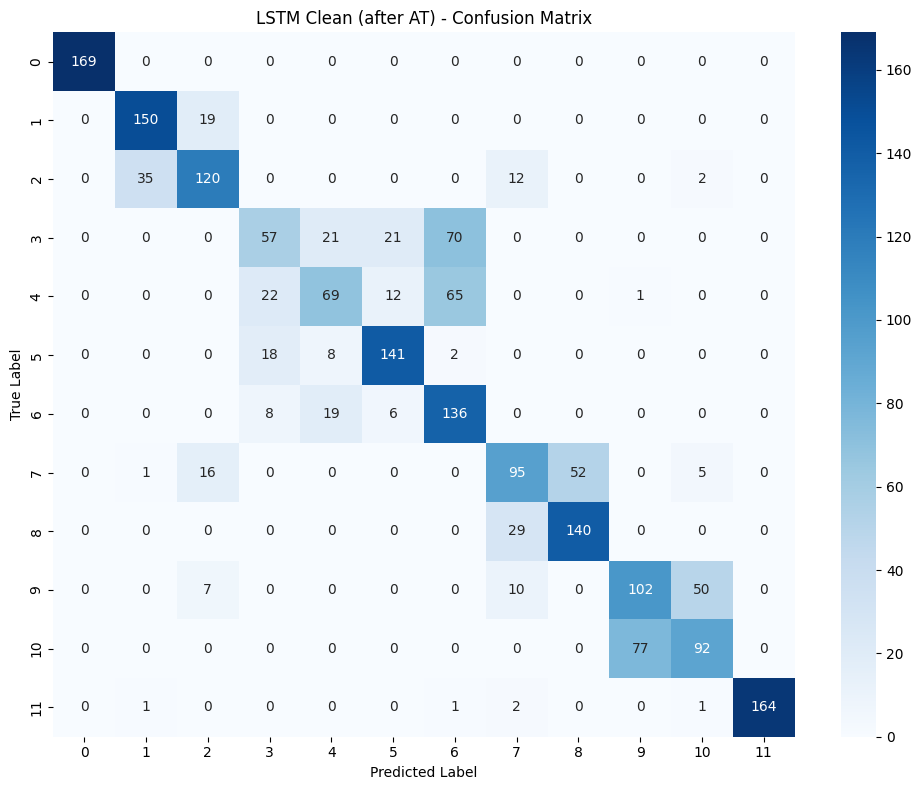

--- LSTM_SC_FGSM (after AT) ---
Accuracy: 70.41%
Precision: 70.55%
Recall: 70.41%
F1 Score: 0.6989


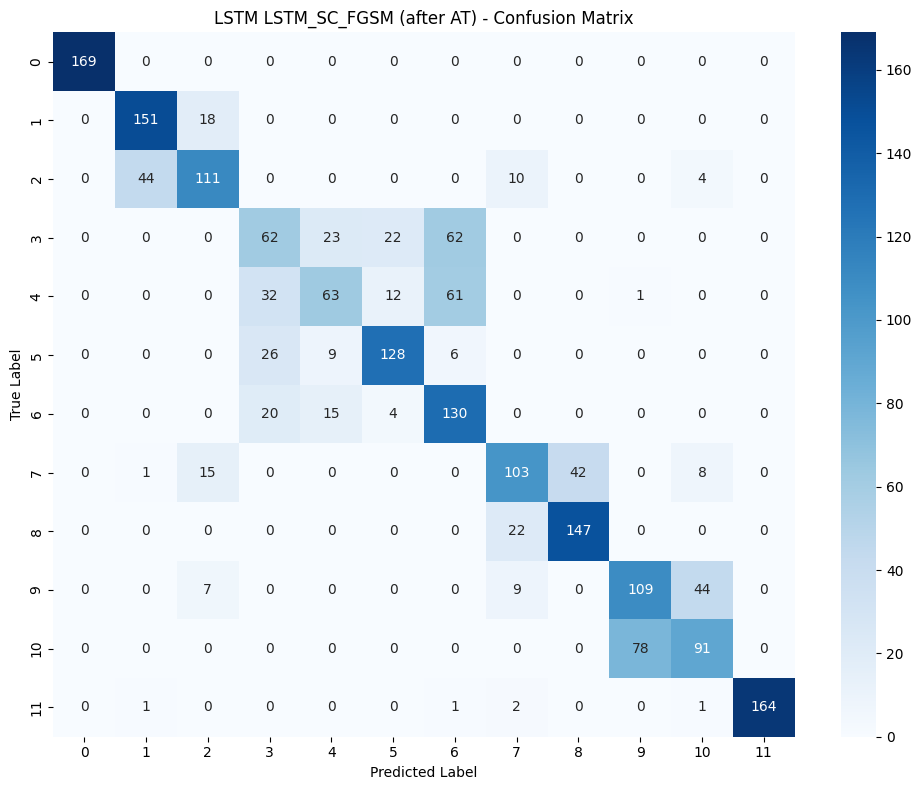

--- LSTM_SC_PGD (after AT) ---
Accuracy: 68.59%
Precision: 68.94%
Recall: 68.59%
F1 Score: 0.6797


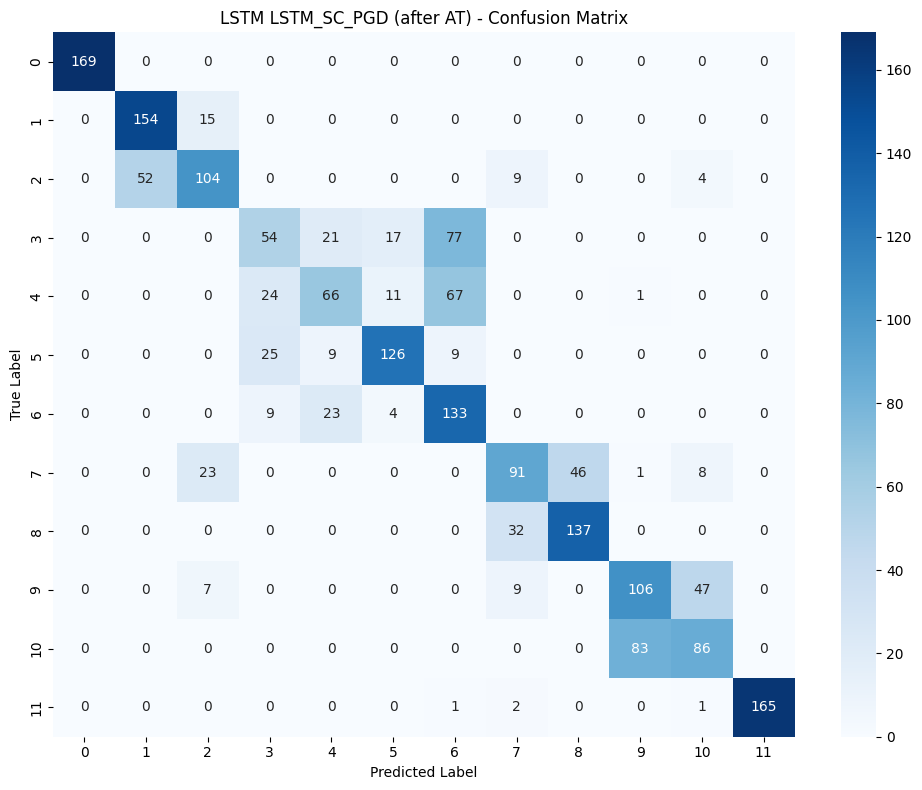

--- LSTM_SC_DEEPFOOL (after AT) ---
Accuracy: 67.21%
Precision: 66.86%
Recall: 67.21%
F1 Score: 0.6629


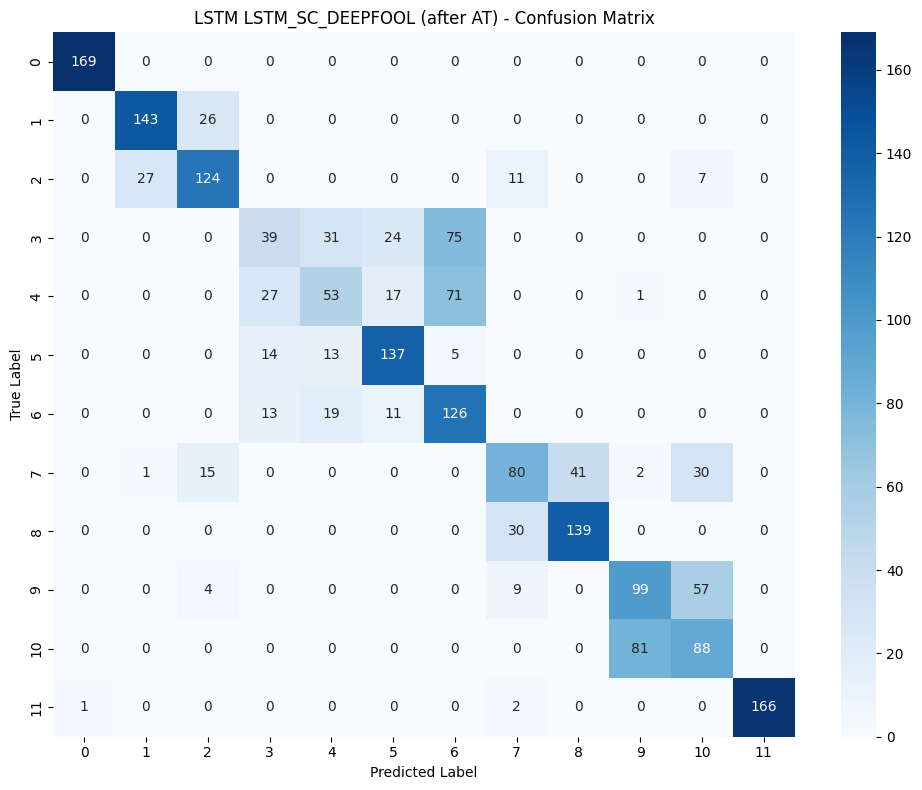

--- LSTM_SC_CW (after AT) ---
Accuracy: 70.86%
Precision: 71.08%
Recall: 70.86%
F1 Score: 0.7019


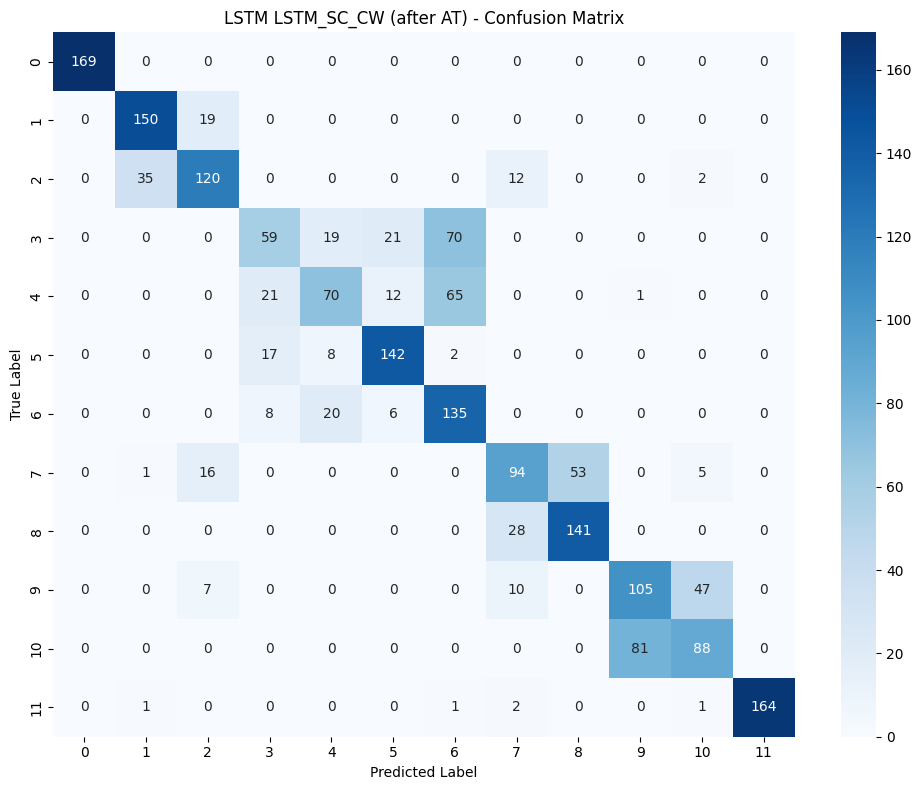

--- LSTM_SC_MIM (after AT) ---
Accuracy: 67.95%
Precision: 67.81%
Recall: 67.95%
F1 Score: 0.6733


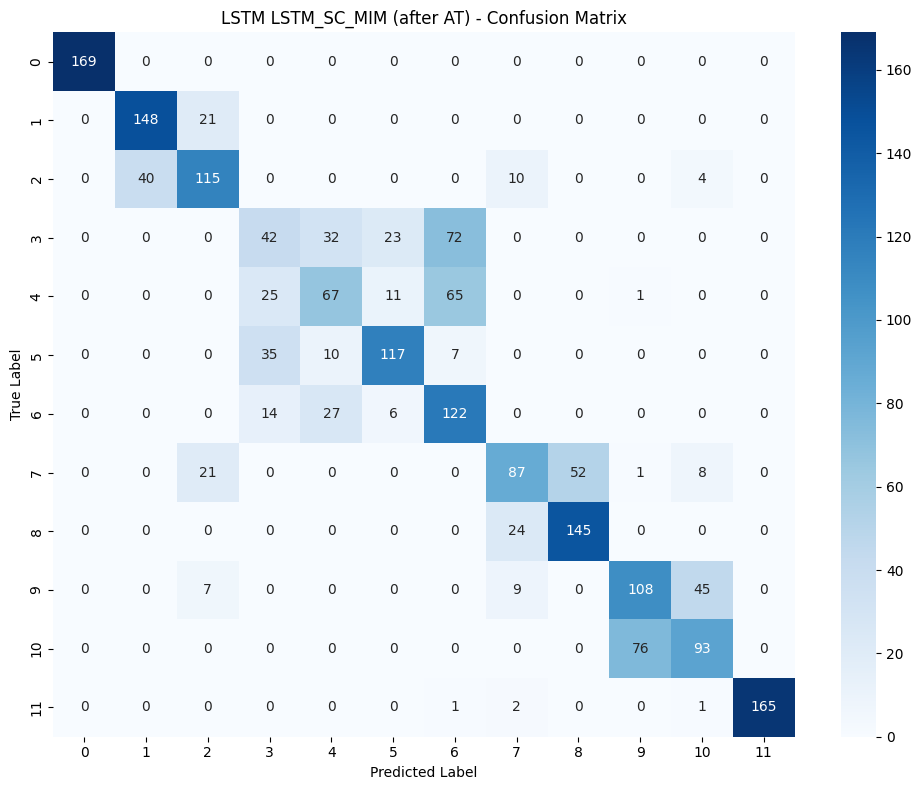

In [27]:
# Load retrained AT model
ckpt_at = torch.load(out_path, map_location=DEVICE, weights_only=False)

lstm_at_net = _LSTMTabular(
    step_dim=int(ckpt_at['step_dim']), hidden=int(ckpt_at['hidden']),
    layers=int(ckpt_at['layers']), n_classes=int(ckpt_at['num_classes']),
    dropout=float(ckpt_at['dropout']), bidir=bool(ckpt_at['bidir']),
)
lstm_at_net.load_state_dict(ckpt_at['state_dict'])
lstm_at_net.eval().to(DEVICE)

scaler_at_loaded = ckpt_at['scaler']

# Scaled-space ART classifier for AT model
X_test_at_sc = scaler_at_loaded.transform(X_test).astype(np.float32)
clip_min_at = float(X_test_at_sc.min())
clip_max_at = float(X_test_at_sc.max())

atk_clf_at = PyTorchClassifier(
    model=lstm_at_net,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(clip_min_at, clip_max_at),
    device_type=DEVICE,
)

# Clean accuracy
preds_clean = atk_clf_at.predict(X_test_at_sc)
evaluate_attack(y_test, preds_clean, 'Clean (after AT)')

# Adv eval — need to re-scale raw adv through AT scaler
for atk_key, adv_raw in adv_eval_data.items():
    adv_at_sc = scaler_at_loaded.transform(adv_raw).astype(np.float32)
    preds_adv = atk_clf_at.predict(adv_at_sc)
    evaluate_attack(y_test, preds_adv, f'{atk_key.upper()} (after AT)')

### 8. ASR comparison

In [28]:
# Before AT (original model, original scaler)
preds_before = atk_clf.predict(X_test_sc)
y_pred_before = np.argmax(preds_before, axis=1)
correct_before = np.where(y_test == y_pred_before)[0]

# After AT (AT model, AT scaler)
preds_after = atk_clf_at.predict(X_test_at_sc)
y_pred_after = np.argmax(preds_after, axis=1)
correct_after = np.where(y_test == y_pred_after)[0]

print('=' * 70)
print('LSTM ASR: Scaled-Space AT (Before -> After)')
print('=' * 70)
print(f'Clean Accuracy: {accuracy_score(y_test, y_pred_before)*100:.2f}% -> '
      f'{accuracy_score(y_test, y_pred_after)*100:.2f}%')
print()

for atk_key, adv_raw in adv_eval_data.items():
    # Before: scale with original scaler
    adv_orig_sc = scaler.transform(adv_raw).astype(np.float32)
    preds_adv_b = np.argmax(atk_clf.predict(adv_orig_sc), axis=1)
    asr_before = np.sum(y_pred_before[correct_before] != preds_adv_b[correct_before]) / len(correct_before) * 100

    # After: scale with AT scaler
    adv_at_sc = scaler_at_loaded.transform(adv_raw).astype(np.float32)
    preds_adv_a = np.argmax(atk_clf_at.predict(adv_at_sc), axis=1)
    asr_after = np.sum(y_pred_after[correct_after] != preds_adv_a[correct_after]) / len(correct_after) * 100

    acc_b = accuracy_score(y_test, preds_adv_b) * 100
    acc_a = accuracy_score(y_test, preds_adv_a) * 100

    print(f'{atk_key.upper():>18s}  Acc: {acc_b:.2f}% -> {acc_a:.2f}%  |  ASR: {asr_before:.2f}% -> {asr_after:.2f}%')

LSTM ASR: Scaled-Space AT (Before -> After)
Clean Accuracy: 68.10% -> 70.76%

      LSTM_SC_FGSM  Acc: 43.93% -> 70.41%  |  ASR: 62.64% -> 6.90%
       LSTM_SC_PGD  Acc: 35.55% -> 68.59%  |  ASR: 72.48% -> 9.48%
  LSTM_SC_DEEPFOOL  Acc: 11.69% -> 67.21%  |  ASR: 100.00% -> 14.08%
        LSTM_SC_CW  Acc: 64.55% -> 70.86%  |  ASR: 9.70% -> 0.49%
       LSTM_SC_MIM  Acc: 36.49% -> 67.95%  |  ASR: 72.34% -> 11.36%
